In [1]:
#Packages
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import collocations
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import time
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from scipy.stats import gaussian_kde

In [2]:
#Pre-Processed Data
dataset_A = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetA_Processed.csv")
dataset_B = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetB_Processed.csv")

In [3]:
dataset_A.columns

Index(['Date', 'Article_title', 'Stock_symbol', 'Article', 'Lsa_summary',
       'Textrank_summary', 'Year', 'Article_Length', 'P_Article_title',
       'P_Article', 'P_LSA', 'P_Textrank_'],
      dtype='str')

In [4]:
dataset_B.columns

Index(['Date', 'Article_title', 'Stock_symbol', 'Article', 'Lsa_summary',
       'Textrank_summary', 'Year', 'Article_Length', 'relevance_score',
       'Relevance_Tier', 'Month', 'P_Article_title', 'P_Article', 'P_LSA',
       'P_Textrank_'],
      dtype='str')

In [5]:
#Creating new dataframes to store only relevant columns
#P represent processed
P_dataset_A = dataset_A[['Date','Stock_symbol','P_Article_title','P_Article']]
P_dataset_A.head(2)

,Date,Stock_symbol,P_Article_title,P_Article
0,2023-12-16,ADSK,adsk quantitative stock analysis,below validea guru fundamental report autodesk...
1,2023-12-16,ADSK,artificial intelligence adding new depth 3d sc...,3d scanner used across wide range industry app...


In [6]:
P_dataset_B = dataset_B[['Date','Stock_symbol','relevance_score','P_Article_title','P_Article']]
P_dataset_B.head(2)

,Date,Stock_symbol,relevance_score,P_Article_title,P_Article
0,2019-01-02,CMCSA,4,fire within netflix stock still burn despite p...,investorplace stock market news stock advice t...
1,2019-01-02,INTC,4,let class action suit dissuade nvidia stock,investorplace stock market news stock advice t...


In [7]:
#Loading the pre-trained components from the Financial Phrasebank Analysis
tfidf = joblib.load('tfidf_vectorizer.pkl')
svm = joblib.load('svm_sentiment_scorer.pkl')
lr = joblib.load('logistic_regression_scorer.pkl')
print("All models loaded successfully!")

All models loaded successfully!


In [8]:
#SVM Sentiment Classification - Dataset A

#Ensuring text columns are clean string arrays
X_titles_A = P_dataset_A['P_Article_title'].astype(str).tolist()
X_articles_A = P_dataset_A['P_Article'].astype(str).tolist()

#Vectorizing the text columns into sparse matrices
X_titles_vecA = tfidf.transform(X_titles_A)
X_articles_vecA = tfidf.transform(X_articles_A)

#Sentiment Scoring - Article Titles - SVM
P_dataset_A['title_svm_label'] = svm.predict(X_titles_vecA)
title_probs = svm.predict_proba(X_titles_vecA)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_A['title_svm_net_sentiment'] = title_probs[:, 2] - title_probs[:, 0]

#Sentiment Scoring - Articles- SVM
P_dataset_A['article_svm_label'] = svm.predict(X_articles_vecA)
article_probs = svm.predict_proba(X_articles_vecA)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_A['article_svm_net_sentiment'] = article_probs[:, 2] - article_probs[:, 0]

print("SVM Pipeline complete! ")

SVM Pipeline complete! 


In [9]:
print(X_titles_vecA.shape)
print(X_articles_vecA.shape)

(60903, 5000)
(60903, 5000)


This proves that the imported phrasebank vectorizer is working as expected.

In [10]:
#SVM Sentiment Classification - Dataset B

#Ensuring text columns are clean string arrays
X_titles_B = P_dataset_B['P_Article_title'].astype(str).tolist()
X_articles_B = P_dataset_B['P_Article'].astype(str).tolist()

#Vectorizing the text columns into sparse matrices
X_titles_vecB = tfidf.transform(X_titles_B)
X_articles_vecB = tfidf.transform(X_articles_B)

#Sentiment Scoring - Article Titles - SVM
P_dataset_B['title_svm_label'] = svm.predict(X_titles_vecB)
title_probs = svm.predict_proba(X_titles_vecB)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_B['title_svm_net_sentiment'] = title_probs[:, 2] - title_probs[:, 0]

#Sentiment Scoring - Articles- SVM
P_dataset_B['article_svm_label'] = svm.predict(X_articles_vecB)
article_probs = svm.predict_proba(X_articles_vecB)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_B['article_svm_net_sentiment'] = article_probs[:, 2] - article_probs[:, 0]

print("SVM Pipeline complete! ")

SVM Pipeline complete! 


In [11]:
#Logistic Regression Sentiment Classification - Dataset A
#Vectorization already done so only sentiment scoring will be executed

#Sentiment Scoring - Article Titles - LR
P_dataset_A['title_lr_label'] = lr.predict(X_titles_vecA)
title_lr_probs = lr.predict_proba(X_titles_vecA)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_A['title_lr_net_sentiment'] = title_lr_probs[:, 2] - title_lr_probs[:, 0]

#Sentiment Scoring - Articles - LR
P_dataset_A['article_lr_label'] = lr.predict(X_articles_vecA)
article_lr_probs = lr.predict_proba(X_articles_vecA)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_A['article_lr_net_sentiment'] = article_lr_probs[:, 2] - article_lr_probs[:, 0]

print("Logistic Regression Pipeline complete!")

Logistic Regression Pipeline complete!


In [12]:
#Logistic Regression Sentiment Classification - Dataset B
#Vectorization already done so only sentiment scoring will be executed

#Sentiment Scoring - Article Titles - LR
P_dataset_B['title_lr_label'] = lr.predict(X_titles_vecB)
title_lr_probs = lr.predict_proba(X_titles_vecB)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_B['title_lr_net_sentiment'] = title_lr_probs[:, 2] - title_lr_probs[:, 0]

#Sentiment Scoring - Articles - LR
P_dataset_B['article_lr_label'] = lr.predict(X_articles_vecB)
article_lr_probs = lr.predict_proba(X_articles_vecB)
#Calculating continuous Net Probability Score (Pos - Neg)
P_dataset_B['article_lr_net_sentiment'] = article_lr_probs[:, 2] - article_lr_probs[:, 0]

print("Logistic Regression Pipeline complete!")

Logistic Regression Pipeline complete!


In [13]:
P_dataset_A.head(2)

,Date,Stock_symbol,P_Article_title,P_Article,title_svm_label,title_svm_net_sentiment,article_svm_label,article_svm_net_sentiment,title_lr_label,title_lr_net_sentiment,article_lr_label,article_lr_net_sentiment
0,2023-12-16,ADSK,adsk quantitative stock analysis,below validea guru fundamental report autodesk...,1,0.033473,1,0.204577,1,0.064626,1,0.167971
1,2023-12-16,ADSK,artificial intelligence adding new depth 3d sc...,3d scanner used across wide range industry app...,1,0.084040,1,0.017371,1,0.161380,1,0.065145


In [14]:
P_dataset_B.head(2)

,Date,Stock_symbol,relevance_score,P_Article_title,P_Article,title_svm_label,title_svm_net_sentiment,article_svm_label,article_svm_net_sentiment,title_lr_label,title_lr_net_sentiment,article_lr_label,article_lr_net_sentiment
0,2019-01-02,CMCSA,4,fire within netflix stock still burn despite p...,investorplace stock market news stock advice t...,1,0.078467,1,0.115701,1,0.089129,1,0.099388
1,2019-01-02,INTC,4,let class action suit dissuade nvidia stock,investorplace stock market news stock advice t...,1,0.040731,2,0.416035,1,0.082986,2,0.222735


In [15]:
#Checking Data types and verifying no missing values
sentiment_cols = [
    'title_svm_label', 'title_svm_net_sentiment',
    'article_svm_label', 'article_svm_net_sentiment',
    'title_lr_label', 'title_lr_net_sentiment',
    'article_lr_label', 'article_lr_net_sentiment'
]

print(P_dataset_A[sentiment_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 60903 entries, 0 to 60902
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title_svm_label            60903 non-null  int64  
 1   title_svm_net_sentiment    60903 non-null  float64
 2   article_svm_label          60903 non-null  int64  
 3   article_svm_net_sentiment  60903 non-null  float64
 4   title_lr_label             60903 non-null  int64  
 5   title_lr_net_sentiment     60903 non-null  float64
 6   article_lr_label           60903 non-null  int64  
 7   article_lr_net_sentiment   60903 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 3.7 MB
None


In [16]:
#Range Validation
print("Net Sentiment Metric Summary Statistics")
display(P_dataset_A[['title_svm_net_sentiment','article_svm_net_sentiment','title_lr_net_sentiment','article_lr_net_sentiment']].describe().loc[['min', 'mean', 'max']])

Net Sentiment Metric Summary Statistics


,title_svm_net_sentiment,article_svm_net_sentiment,title_lr_net_sentiment,article_lr_net_sentiment
min,-0.999237,-0.999671,-0.954751,-0.954751
mean,0.101566,0.246887,0.083925,0.160471
max,0.999985,0.999999,0.906086,0.920746


The min values are not less than -1.0, The max values are not greater than 1.0.

In [17]:
#Correlation Check
print("Model Feature Correlations")
title_corr = P_dataset_A['title_svm_net_sentiment'].corr(P_dataset_A['title_lr_net_sentiment'])
article_corr = P_dataset_A['article_svm_net_sentiment'].corr(P_dataset_A['article_lr_net_sentiment'])

print(f"Title Correlation: {title_corr:.2f}")
print(f"Article Correlation: {article_corr:.2f}")

Model Feature Correlations
Title Correlation: 0.92
Article Correlation: 0.94


The very strong positive correlation empirically proves that both models are moving in harmony when evaluating market data.

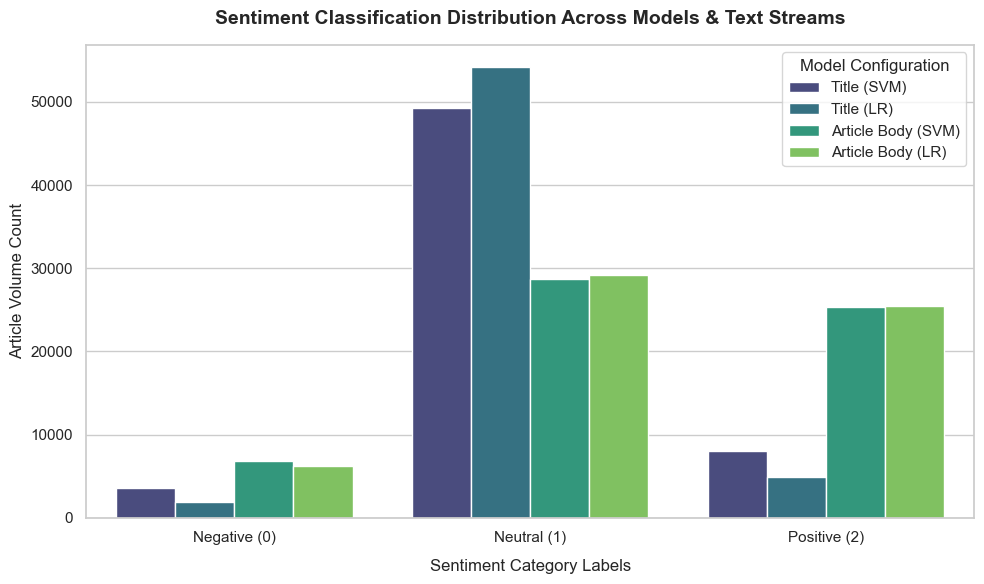

In [18]:
#Sentiment Distribution (Bar Chart)

#Ensures DataFrame is compatible with Seaborn's hue mapping
dist_df = P_dataset_A[['title_svm_label', 'title_lr_label', 'article_svm_label', 'article_lr_label']].melt(
    var_name='Model_Type', value_name='Sentiment_Class'
)

#Cleaning up column names for better display
name_map = {
    'title_svm_label': 'Title (SVM)',
    'title_lr_label': 'Title (LR)',
    'article_svm_label': 'Article Body (SVM)',
    'article_lr_label': 'Article Body (LR)'
}
dist_df['Model_Type'] = dist_df['Model_Type'].map(name_map)

#Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=dist_df, 
    x='Sentiment_Class', 
    hue='Model_Type', 
    palette='viridis'
)

plt.title('Sentiment Classification Distribution Across Models & Text Streams', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category Labels', fontsize=12, labelpad=10)
plt.ylabel('Article Volume Count', fontsize=12)
plt.xticks([0, 1, 2], ['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.legend(title='Model Configuration', frameon=True)

plt.tight_layout()
plt.savefig('sentiment_distribution_comparison.png', dpi=300)
plt.show()

This chart visually demonstrates the media optimism bias with the highest article volume count falling under the neutral category. It also shows the sentiment classification alignment between the two models.

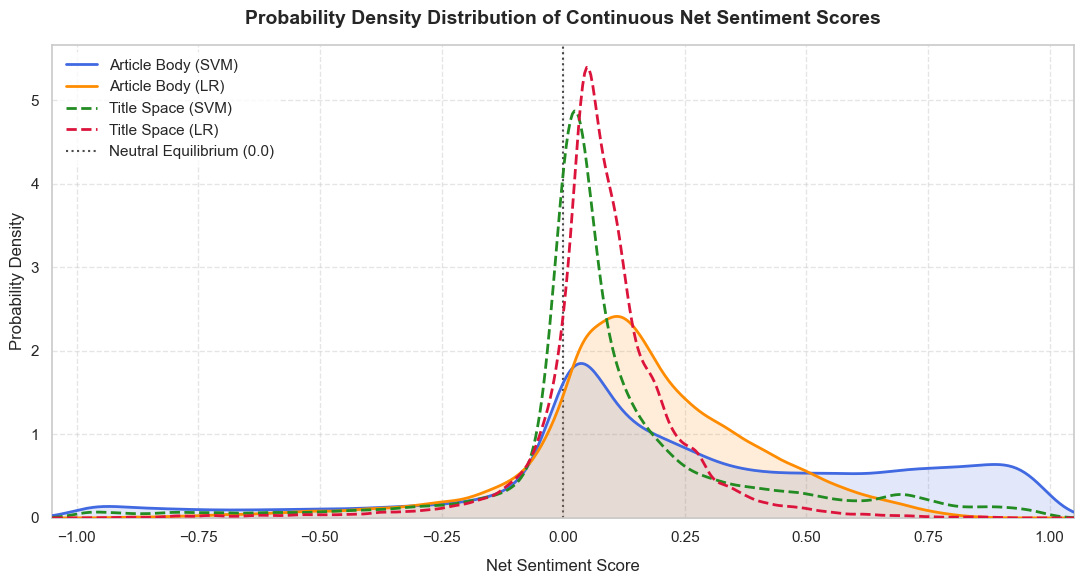

In [19]:
#Probability Density Distribution 
sentiment_cols = [
    'article_svm_net_sentiment', 'article_lr_net_sentiment',
    'title_svm_net_sentiment', 'title_lr_net_sentiment'
]

plot_data = P_dataset_A[sentiment_cols].dropna().copy()

#Plot layout
plt.figure(figsize=(11, 6))
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

#Defining configuration parameters for clean visualization
configs = [
    {'col': 'article_svm_net_sentiment', 'label': 'Article Body (SVM)', 'color': 'royalblue', 'style': '-'},
    {'col': 'article_lr_net_sentiment', 'label': 'Article Body (LR)', 'color': 'darkorange', 'style': '-'},
    {'col': 'title_svm_net_sentiment', 'label': 'Title Space (SVM)', 'color': 'forestgreen', 'style': '--'},
    {'col': 'title_lr_net_sentiment', 'label': 'Title Space (LR)', 'color': 'crimson', 'style': '--'}
]

#Plotting the KDE curves using SciPy
x_evaluation_range = np.linspace(-1.05, 1.05, 500)

for config in configs:
    #Extracts data array
    data_vector = plot_data[config['col']].values
    
    #Calculates the mathematical Kernel Density Estimate
    kde_engine = gaussian_kde(data_vector)
    density_curve = kde_engine(x_evaluation_range)
    
    #Plotting the continuous line
    plt.plot(
        x_evaluation_range, density_curve, 
        label=config['label'], color=config['color'], 
        linestyle=config['style'], linewidth=2, zorder=3
    )
    
    if config['style'] == '-':
        plt.fill_between(
            x_evaluation_range, 0, density_curve, 
            color=config['color'], alpha=0.15, zorder=2
        )

#Vertical baseline representing neutral market sentiment
plt.axvline(x=0.0, color='black', linestyle=':', alpha=0.7, label='Neutral Equilibrium (0.0)', zorder=1)


plt.title('Probability Density Distribution of Continuous Net Sentiment Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Net Sentiment Score', fontsize=12, labelpad=10)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(-1.05, 1.05)
plt.ylim(bottom=0) 
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.savefig('net_sentiment_density_pure_mpl.png', dpi=300)
plt.show()

The plot shows that a massive chunk of the news articles hover right around the neutral to positive area. This reveals that the dataset consists mostly of steady news, punctuated by occasional, extreme market crashes or corporate collapses. The neutrality trap is mainly because financial news journalists tend to be objective, so their language is highly measured.

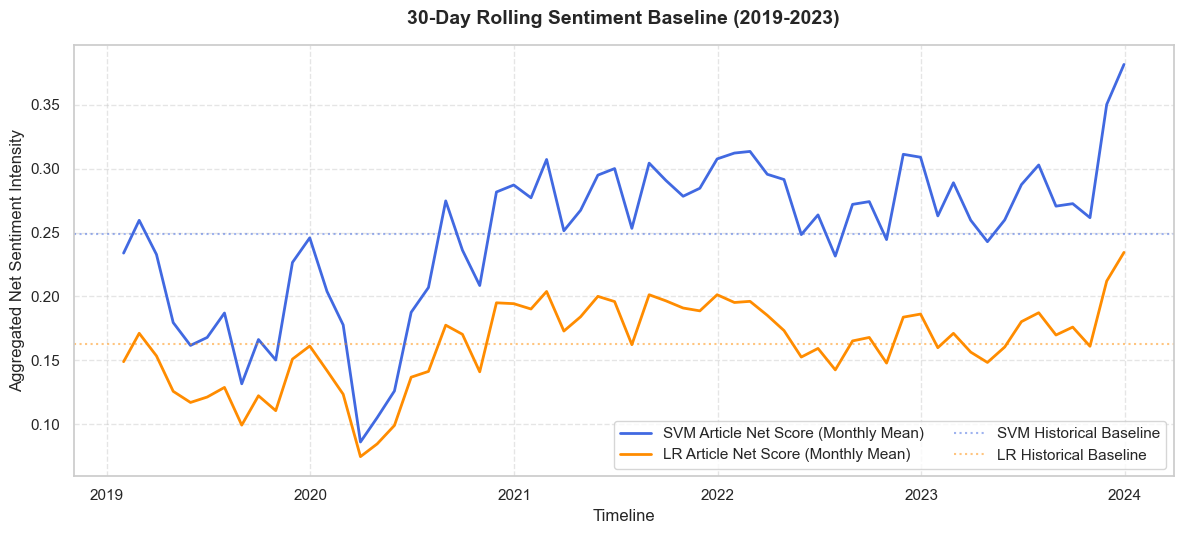

In [20]:
#Sentiment Trajectory Plot
time_df = P_dataset_A[['Date', 'article_svm_net_sentiment', 'article_lr_net_sentiment']].copy()
time_df['Date'] = pd.to_datetime(time_df['Date'])
time_df.set_index('Date', inplace=True)

#Resample to Monthly Average to smooth out daily noise for a clean display
monthly_sentiment = time_df.resample('ME').mean() #Month End

plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sentiment.index, monthly_sentiment['article_svm_net_sentiment'], label='SVM Article Net Score (Monthly Mean)', color='royalblue', linewidth=2)
plt.plot(monthly_sentiment.index, monthly_sentiment['article_lr_net_sentiment'], label='LR Article Net Score (Monthly Mean)', color='darkorange', linewidth=2)

plt.axhline(y=monthly_sentiment['article_svm_net_sentiment'].mean(), color='royalblue', linestyle=':', alpha=0.5, label='SVM Historical Baseline')
plt.axhline(y=monthly_sentiment['article_lr_net_sentiment'].mean(), color='darkorange', linestyle=':', alpha=0.5, label='LR Historical Baseline')

plt.title('30-Day Rolling Sentiment Baseline (2019-2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Aggregated Net Sentiment Intensity', fontsize=12)
plt.legend(loc='lower right', frameon=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('macro_sentiment_timeline.png', dpi=300)
plt.show()

The above sentiment projection provides immediate, empirical proof that the models are not just calculating random noise but actively capturing macro-economic reality. The significant dip in early March 2020 reflects an unprecedented economy shock as the COVID-19 pandemic triggered widespread lockdowns. The financial markets reacted with extreme volatility, leading to the fastest bear market. This means that during this period, the text corpus was heavily saturated with high-intensity negative financial vocabulary. Both the models successfully picked up on this shift.

The Sentiment Rebound (Late 2020–2021)represents the massive influx of media coverage surrounding central bank stimulus packages, technology sector growth, and economic reopening narratives.In 2022, there is a more gradual prolonged dip which corresponds to the Federal Reserve's aggressive interest rate hiking cycle and the 2022 bear market.

Seeing these macroeconomic milestones reflected perfectly validates the model's capacity to extract macro-sentimental anomalies from unstructured text before these features are transitioned into the predictive modeling framework.